## 1. Setup and Imports {#setup}

Let's start by importing all necessary modules and setting up the environment.

In [ ]:
cd ../

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys
import os
warnings.filterwarnings('ignore')

import sys
import os
sys.path.insert(0, '/home/HX46_FR5/github/AbXtract')


from AbXtract import *
from AbXtract import AntibodyDescriptorCalculator, Config, load_config
from AbXtract.sequence import (
    SequenceLiabilityAnalyzer,
    BashourDescriptorCalculator,
    PeptideDescriptorCalculator,
    AntibodyNumbering
)
from AbXtract.structure import (
    SASACalculator,
    ChargeAnalyzer,
    DSSPAnalyzer,
    PropkaAnalyzer,
    ArpeggioAnalyzer
)
from AbXtract.utils import (
    read_fasta,
    write_fasta,
    parse_sequence,
    validate_sequence,
    analysis_descriptors
)


# 2. Function to combine descriptors and class them

In [13]:
def desc_Ab(HEAVY_SEQUENCE, LIGHT_SEQUENCE, PDB_FILE):
    
    if HEAVY_SEQUENCE:
        heavy_valid, heavy_msg = validate_sequence(HEAVY_SEQUENCE)
        heavy_numbered = numbering.number_sequence(HEAVY_SEQUENCE, 'H')  # Use VH portion only
        annotated_H, cdrs_H = numbering.get_cdr_sequences(heavy_numbered, 'H')
        heavy_profiles = numbering.get_peptide_profiles(HEAVY_SEQUENCE)
    
    if LIGHT_SEQUENCE:
        light_valid, light_msg = validate_sequence(LIGHT_SEQUENCE)
        light_numbered = numbering.number_sequence(LIGHT_SEQUENCE, 'L')  # Use VH portion only    
        annotated_L, cdrs_L = numbering.get_cdr_sequences(light_numbered, 'L')
        light_profiles = numbering.get_peptide_profiles(LIGHT_SEQUENCE)
    else:
        light_valid = False
        cdrs_L = False

    peptide_results = peptide_calc.calculate_all(
    heavy_sequence=HEAVY_SEQUENCE,
    light_sequence=LIGHT_SEQUENCE
    )

    sequence_results, liabilities = calc.calculate_sequence_descriptors(
    heavy_sequence=HEAVY_SEQUENCE,
    light_sequence=LIGHT_SEQUENCE,
    sequence_id="TestAb_Sequence"
    )

    structure_results_seq, structure_results_comp, df_residues, df_AA, df_Ab = calc.calculate_structure_descriptors(
    heavy_sequence=HEAVY_SEQUENCE,
    light_sequence=LIGHT_SEQUENCE,
    pdb_file=PDB_FILE,
    structure_id="TestAb_Structure"
    )
    
        
    # Ensure residue_sasa_sum column exists
    structures_results_seq = analysis_descriptors.add_residue_sasa_sum_column(structure_results_seq)

    # Get data
    liabilities_list = liabilities['liabilities'].iloc[0]
    structures_data = structures_results_seq.iloc[0]

    if HEAVY_SEQUENCE:
        df_heavy_final = analysis_descriptors.create_complete_antibody_dataframe( 0, df_residues, df_Ab, 
            HEAVY_SEQUENCE, annotated_H, heavy_profiles, 
            structures_data, liabilities_list, 'Heavy', 'imgt'
                                                           
        )
    else:
        df_light_final = None
        
    if LIGHT_SEQUENCE:
        df_light_final = analysis_descriptors.create_complete_antibody_dataframe(len(HEAVY_SEQUENCE), df_residues, df_Ab, 
            LIGHT_SEQUENCE, annotated_L, light_profiles,
            structures_data, liabilities_list, 'Light', 'imgt'
                                                            
        )
    else:
        df_light_final = None
        
    df_final = analysis_descriptors.combine_all_results(
        df_AA,
        structure_results_comp,
        sequence_results,
        peptide_results,
        heavy_valid=heavy_valid,
        light_valid=light_valid,
        cdrs_H=cdrs_H,
        cdrs_L=cdrs_L
    )

    return(df_heavy_final, df_light_final, df_final)

# Load config

In [3]:
# default configuration
custom_config = Config()

'''
# Test custom configuration
custom_config = Config.from_dict({
    'pH': 7.4,
    'numbering_scheme': 'kabat',
    'verbose': True,
    'calculate_dssp': tool_status.get('dssp', False),
    'calculate_propka': tool_status.get('propka', False),
    'calculate_arpeggio': tool_status.get('arpeggio', False)
})
'''


# Check external tool availability
tool_status = custom_config.check_external_tools()
print("🛠️ External Tool Status:")
for tool, available in tool_status.items():
    status = "✅" if available else "❌"
    print(f"  {tool}: {status}")


reduce not found at reduce


🛠️ External Tool Status:
  dssp: ✅
  propka: ✅
  arpeggio: ✅
  reduce: ❌
  muscle: ✅


# Load classes

In [4]:
numbering = AntibodyNumbering(scheme='imgt')
peptide_calc = PeptideDescriptorCalculator()
calc = AntibodyDescriptorCalculator(config=custom_config)

reduce not found at reduce
Missing external tools: reduce
Some analyses may not be available


--- 0.4890565872192383 seconds --- INITIALIZATION


# Define path 

In [5]:
abxtract_path = "/home/HX46_FR5/repo_perso/AbXtract"
sys.path.insert(0, abxtract_path)

# Set up test data paths
BASE_DIR = Path.cwd() 
DATA_DIR = BASE_DIR / "data" / "test_VH"
DATA_DIR.mkdir(parents=True, exist_ok=True)


# Define test file paths
RESULTS_DIR = DATA_DIR / "results_VH"
RESULTS_DIR.mkdir(exist_ok=True)


# Input sequence and pdb

In [6]:
ids_Ab = ["BsAb-3981-[38133.38699-38133.38509]",
"BsAb-3982-[38134.38700-38134.38510]",
"BsAb-4600-[39296.39495-39296.39581]",
"BsAb-4604-[39300.39499-39300.39585]",
"BsAb-4605-[39301.39500-39301.39586]",
"BsAb-4609-[39305.39504-39305.39590]",
"BsAb-4608-[39304.39503-39304.39589]",
"BsAb-4598-[39294.39493-39294.39579]",
"BsAb-4621-[39317.39516-39317.39602]",
"BsAb-4611-[39307.39506-39307.39592]",
"BsAb-3983-[38135.38701-38135.38511]",
"BsAb-3984-[38136.38702-38136.38512]",
"BsAb-3985-[38137.38703-38137.38513]",
"BsAb-3986-[38138.38704-38138.38514]",
"BsAb-3987-[38139.38705-38139.38515]",
"BsAb-3988-[38140.38706-38140.38516]",
"BsAb-3989-[38141.38707-38141.38517]",
"BsAb-3990-[38142.38708-38142.38518]",
"BsAb-3992-[38144.38710-38144.38520]",
"BsAb-3993-[38145.38711-38145.38521]",
"BsAb-3994-[38146.38712-38146.38522]",
"BsAb-3995-[38147.38713-38147.38523]",
"BsAb-3996-[38148.38714-38148.38524]",
"BsAb-3997-[38149.38715-38149.38525]",
"BsAb-3998-[38150.38716-38150.38526]",
"BsAb-3999-[38151.38717-38151.38527]",
"BsAb-4000-[38152.38718-38152.38528]",
"BsAb-4001-[38153.38719-38153.38529]",
"BsAb-4002-[38154.38720-38154.38530]",
"BsAb-4603-[39299.39498-39299.39584]",
"BsAb-4305-[38441.39026-38441.39121]",
"BsAb-4306-[38441.39027-38441.39122]",
"BsAb-4304-[38440.39025-38440.39120]",
"BsAb-4619-[39315.39514-39315.39600]",
"BsAb-4610-[39306.39505-39306.39591]",
"BsAb-4607-[39303.39502-39303.39588]",
"BsAb-4003-[38155.38721-38155.38531]",
"BsAb-4004-[38156.38722-38156.38532]",
"BsAb-4005-[38157.38723-38157.38533]",
"BsAb-4599-[39295.39494-39295.39580]",
"BsAb-4006-[38158.38724-38158.38534]",
"BsAb-4007-[38159.38725-38159.38535]",
"BsAb-4008-[38160.38726-38160.38536]",
"BsAb-2995-[37161.37256-37161.37161]",
"BsAb-2996-[37162.37257-37162.37162]",
"BsAb-3510-[37394.37432-37394.37394]",
"BsAb-3509-[37393.37431-37393.37393]",
"BsAb-2997-[37163.37258-37163.37163]",
"BsAb-2998-[37164.37259-37164.37164]",
"BsAb-2999-[37165.37260-37165.37165]",
"BsAb-3000-[37166.37261-37166.37166]",
"BsAb-3518-[37402.37440-37402.37402]",
"BsAb-3500-[37384.37422-37384.37384]",
"BsAb-3488-[37372.37410-37372.37372]",
"BsAb-4024-[38176.38742-38176.38552]",
"BsAb-4092-[38244.38810-38244.38620]",
"BsAb-4310-[38445.39031-38445.39126]",
"BsAb-4308-[38443.39029-38443.39124]",
"BsAb-4320-[38452.39041-38452.39136]",
"BsAb-4311-[38445.39032-38445.39127]",
"BsAb-4325-[38457.39046-38457.39141]",
"BsAb-4321-[38453.39042-38453.39137]",
"BsAb-4329-[38461.39050-38461.39145]",
"BsAb-4324-[38456.39045-38456.39140]",
"BsAb-4640-[39336.39535-39336.39621]",
"BsAb-4322-[38454.39043-38454.39138]",
"BsAb-4309-[38444.39030-38444.39125]",
"BsAb-4336-[38468.39057-38468.39152]",
"BsAb-4641-[39337.39536-39337.39622]",
"BsAb-4630-[39326.39525-39326.39611]",
"BsAb-4327-[38459.39048-38459.39143]",
"BsAb-4160-[38312.38878-38312.38688]",
"BsAb-4333-[38465.39054-38465.39149]",
"BsAb-4332-[38464.39053-38464.39148]",
"BsAb-4132-[38284.38850-38284.38660]",
"BsAb-4060-[38212.38778-38212.38588]",
"BsAb-4122-[38274.38840-38274.38650]",
"BsAb-4143-[38295.38861-38295.38671]",
"BsAb-4129-[38281.38847-38281.38657]",
"BsAb-4055-[38207.38773-38207.38583]",
"BsAb-4066-[38218.38784-38218.38594]",
"BsAb-4104-[38256.38822-38256.38632]",
"BsAb-4097-[38249.38815-38249.38625]",
"BsAb-4090-[38242.38808-38242.38618]",
"BsAb-4025-[38177.38743-38177.38553]",
"BsAb-4069-[38221.38787-38221.38597]",
"BsAb-4070-[38222.38788-38222.38598]",
"BsAb-4032-[38184.38750-38184.38560]",
"BsAb-4146-[38298.38864-38298.38674]",
"BsAb-3979-[38131.38697-38131.38507]",
"BsAb-4063-[38215.38781-38215.38591]",
"BsAb-4084-[38236.38802-38236.38612]",
"BsAb-4009-[38161.38727-38161.38537]",
"BsAb-4315-[38448.39036-38448.39131]",
"BsAb-4152-[38304.38870-38304.38680]",
"BsAb-4100-[38252.38818-38252.38628]",
"BsAb-4275-[38417.38996-38417.39091]",
"BsAb-4053-[38205.38771-38205.38581]",
"BsAb-4154-[38306.38872-38306.38682]",
"BsAb-4061-[38213.38779-38213.38589]",
"BsAb-4156-[38308.38874-38308.38684]",
"BsAb-4124-[38276.38842-38276.38652]",
"BsAb-4278-[38420.38999-38420.39094]",
"BsAb-4101-[38253.38819-38253.38629]",
"BsAb-4159-[38311.38877-38311.38687]",
"BsAb-4120-[38272.38838-38272.38648]",
"BsAb-4042-[38194.38760-38194.38570]",
"BsAb-4271-[38413.38992-38413.39087]",
"BsAb-4274-[38416.38995-38416.39090]",
"BsAb-4273-[38415.38994-38415.39089]",
"BsAb-4269-[38412.38990-38412.39085]",
"BsAb-4279-[38421.39000-38421.39095]",
"BsAb-4280-[38422.39001-38422.39096]",
"BsAb-4093-[38245.38811-38245.38621]",
"BsAb-4155-[38307.38873-38307.38683]",
"BsAb-4035-[38187.38753-38187.38563]",
"BsAb-4067-[38219.38785-38219.38595]",
"BsAb-4087-[38239.38805-38239.38615]",
"BsAb-4108-[38260.38826-38260.38636]",
"BsAb-4111-[38263.38829-38263.38639]",
"BsAb-4105-[38257.38823-38257.38633]",
"BsAb-4049-[38201.38767-38201.38577]",
"BsAb-4045-[38197.38763-38197.38573]",
"BsAb-4041-[38193.38759-38193.38569]",
"BsAb-4151-[38303.38869-38303.38679]",
"BsAb-4095-[38247.38813-38247.38623]",
"BsAb-4115-[38267.38833-38267.38643]",
"BsAb-4653-[39349.39548-39349.39634]",
"BsAb-4010-[38162.38728-38162.38538]",
"BsAb-4098-[38250.38816-38250.38626]",
"BsAb-4011-[38163.38729-38163.38539]",
"BsAb-4157-[38309.38875-38309.38685]",
"BsAb-4651-[39347.39546-39347.39632]",
"BsAb-4134-[38286.38852-38286.38662]",
"BsAb-4138-[38290.38856-38290.38666]",
"BsAb-4012-[38164.38730-38164.38540]",
"BsAb-4013-[38165.38731-38165.38541]",
"BsAb-4014-[38166.38732-38166.38542]",
"BsAb-4015-[38167.38733-38167.38543]",
"BsAb-4016-[38168.38734-38168.38544]",
"BsAb-4103-[38255.38821-38255.38631]",
"BsAb-4133-[38285.38851-38285.38661]",
"BsAb-4082-[38234.38800-38234.38610]",
"BsAb-4141-[38293.38859-38293.38669]",
"BsAb-4147-[38299.38865-38299.38675]",
"BsAb-4094-[38246.38812-38246.38622]",
"BsAb-4162-[38314.38880-38314.38690]",
"BsAb-4647-[39343.39542-39343.39628]",
"BsAb-4166-[38318.38884-38318.38694]",
"BsAb-4110-[38262.38828-38262.38638]",
"BsAb-4088-[38240.38806-38240.38616]",
"BsAb-4056-[38208.38774-38208.38584]",
"BsAb-4153-[38305.38871-38305.38681]",
"BsAb-4127-[38279.38845-38279.38655]",
"BsAb-4135-[38287.38853-38287.38663]",
"BsAb-4017-[38169.38735-38169.38545]",
"BsAb-4164-[38316.38882-38316.38692]",
"BsAb-4079-[38231.38797-38231.38607]",
"BsAb-4037-[38189.38755-38189.38565]",
"BsAb-4317-[38450.39038-38450.39133]",
"BsAb-4314-[38447.39035-38447.39130]",
"BsAb-4051-[38203.38769-38203.38579]",
"BsAb-4137-[38289.38855-38289.38665]",
"BsAb-4109-[38261.38827-38261.38637]",
"BsAb-4117-[38269.38835-38269.38645]",
"BsAb-4589-[39285.39484-39285.39570]",
"BsAb-4163-[38315.38881-38315.38691]",
"BsAb-4334-[38466.39055-38466.39150]",
"BsAb-4119-[38271.38837-38271.38647]",
"BsAb-4083-[38235.38801-38235.38611]",
"BsAb-4116-[38268.38834-38268.38644]",
"BsAb-4048-[38200.38766-38200.38576]",
"BsAb-4150-[38302.38868-38302.38678]",
"BsAb-4062-[38214.38780-38214.38590]",
"BsAb-4331-[38463.39052-38463.39147]",
"BsAb-4058-[38210.38776-38210.38586]",
"BsAb-4052-[38204.38770-38204.38580]",
"BsAb-4044-[38196.38762-38196.38572]",
"BsAb-4043-[38195.38761-38195.38571]",
"BsAb-4033-[38185.38751-38185.38561]",
"BsAb-4096-[38248.38814-38248.38624]",
"BsAb-4106-[38258.38824-38258.38634]",
"BsAb-4040-[38192.38758-38192.38568]",
"BsAb-4293-[38432.39014-38432.39109]",
"BsAb-4148-[38300.38866-38300.38676]",
"BsAb-4114-[38266.38832-38266.38642]",
"BsAb-4059-[38211.38777-38211.38587]",
"BsAb-4057-[38209.38775-38209.38585]",
"BsAb-4050-[38202.38768-38202.38578]",
"BsAb-4036-[38188.38754-38188.38564]",
"BsAb-4140-[38292.38858-38292.38668]",
"BsAb-4080-[38232.38798-38232.38608]",
"BsAb-4039-[38191.38757-38191.38567]",
"BsAb-4078-[38230.38796-38230.38606]",
"BsAb-4064-[38216.38782-38216.38592]",
"BsAb-4076-[38228.38794-38228.38604]",
"BsAb-4168-[38320.38886-38320.38696]",
"BsAb-4161-[38313.38879-38313.38689]",
"BsAb-4068-[38220.38786-38220.38596]",
"BsAb-4128-[38280.38846-38280.38656]",
"BsAb-4054-[38206.38772-38206.38582]",
"BsAb-4125-[38277.38843-38277.38653]",
"BsAb-4646-[39342.39541-39342.39627]",
"BsAb-4649-[39345.39544-39345.39630]",
"BsAb-4596-[39292.39491-39292.39577]",
"BsAb-4034-[38186.38752-38186.38562]",
"BsAb-4091-[38243.38809-38243.38619]",
"BsAb-4089-[38241.38807-38241.38617]",
"BsAb-4328-[38460.39049-38460.39144]",
"BsAb-4099-[38251.38817-38251.38627]",
"BsAb-4107-[38259.38825-38259.38635]",
"BsAb-4123-[38275.38841-38275.38651]",
"BsAb-4046-[38198.38764-38198.38574]",
"BsAb-4074-[38226.38792-38226.38602]",
"BsAb-4112-[38264.38830-38264.38640]",
"BsAb-4650-[39346.39545-39346.39631]",
"BsAb-4648-[39344.39543-39344.39629]",
"BsAb-4065-[38217.38783-38217.38593]",
"BsAb-4643-[39339.39538-39339.39624]",
"BsAb-4644-[39340.39539-39340.39625]",
"BsAb-4636-[39332.39531-39332.39617]",
"BsAb-4635-[39331.39530-39331.39616]",
"BsAb-4634-[39330.39529-39330.39615]",
"BsAb-4623-[39319.39518-39319.39604]",
"BsAb-4645-[39341.39540-39341.39626]",
"BsAb-4627-[39323.39522-39323.39608]",
"BsAb-4594-[39290.39489-39290.39575]",
"BsAb-3001-[37167.37262-37167.37167]",
"BsAb-4145-[38297.38863-38297.38673]",
"BsAb-4077-[38229.38795-38229.38605]",
"BsAb-4113-[38265.38831-38265.38641]",
"BsAb-4158-[38310.38876-38310.38686]",
"BsAb-4592-[39288.39487-39288.39573]",
"BsAb-4075-[38227.38793-38227.38603]",
"BsAb-4038-[38190.38756-38190.38566]",
"BsAb-4026-[38178.38744-38178.38554]",
"BsAb-4027-[38179.38745-38179.38555]",
"BsAb-4028-[38180.38746-38180.38556]",
"BsAb-4029-[38181.38747-38181.38557]",
"BsAb-4126-[38278.38844-38278.38654]",
"BsAb-4086-[38238.38804-38238.38614]",
"BsAb-4165-[38317.38883-38317.38693]",
"BsAb-4085-[38237.38803-38237.38613]",
"BsAb-4047-[38199.38765-38199.38575]",
"BsAb-4081-[38233.38799-38233.38609]",
"BsAb-4030-[38182.38748-38182.38558]",
"BsAb-4118-[38270.38836-38270.38646]",
"BsAb-4136-[38288.38854-38288.38664]",
"BsAb-4149-[38301.38867-38301.38677]",
"BsAb-4131-[38283.38849-38283.38659]",
"BsAb-4130-[38282.38848-38282.38658]",
"BsAb-4121-[38273.38839-38273.38649]",
"BsAb-4652-[39348.39547-39348.39633]",
"BsAb-4142-[38294.38860-38294.38670]",
"BsAb-4289-[38429.39010-38429.39105]",
"BsAb-4290-[38429.39011-38429.39106]",
"BsAb-4139-[38291.38857-38291.38667]",
"BsAb-4144-[38296.38862-38296.38672]",
"BsAb-4072-[38224.38790-38224.38600]",
"BsAb-4018-[38170.38736-38170.38546]",
"BsAb-4019-[38171.38737-38171.38547]",
"BsAb-4287-[38427.39008-38427.39103]",
"BsAb-4286-[38426.39007-38426.39102]",
"BsAb-4285-[38425.39006-38425.39101]",
"BsAb-4590-[39286.39485-39286.39571]",
"BsAb-4584-[39280.39479-39280.39565]",
"BsAb-4582-[39277.39477-39277.39563]",
"BsAb-4282-[38423.39003-38423.39098]",
"BsAb-4597-[39293.39492-39293.39578]",
"BsAb-4659-[39355.39554-39355.39640]",
"BsAb-4020-[38172.38738-38172.38548]",
"BsAb-4031-[38183.38749-38183.38559]",
"BsAb-3486-[37370.37408-37370.37370]",
"BsAb-4292-[38431.39013-38431.39108]",
"BsAb-4071-[38223.38789-38223.38599]",
"BsAb-4021-[38173.38739-38173.38549]",
"BsAb-4167-[38319.38885-38319.38695]",
"BsAb-4102-[38254.38820-38254.38630]",
"BsAb-4022-[38174.38740-38174.38550]",
"BsAb-4023-[38175.38741-38175.38551]",
"BsAb-3002-[37168.37263-37168.37168]",
"BsAb-3003-[37169.37264-37169.37169]",
"BsAb-3010-[37176.37271-37176.37176]",
"BsAb-3004-[37170.37265-37170.37170]",
"BsAb-3005-[37171.37266-37171.37171]",
"BsAb-3006-[37172.37267-37172.37172]",
"BsAb-3007-[37173.37268-37173.37173]",
"BsAb-3008-[37174.37269-37174.37174]",
"BsAb-3501-[37385.37423-37385.37385]",
"BsAb-3009-[37175.37270-37175.37175]",
"BsAb-3011-[37177.37272-37177.37177]",
"BsAb-3495-[37379.37417-37379.37379]",
"BsAb-3018-[37184.37279-37184.37184]",
"BsAb-3019-[37185.37280-37185.37185]",
"BsAb-3020-[37186.37281-37186.37186]",
"BsAb-3483-[37367.37405-37367.37367]",
"BsAb-3021-[37187.37282-37187.37187]",
"BsAb-3012-[37178.37273-37178.37178]",
"BsAb-3013-[37179.37274-37179.37179]",
"BsAb-3014-[37180.37275-37180.37180]",
"BsAb-3015-[37181.37276-37181.37181]",
"BsAb-3016-[37182.37277-37182.37182]",
"BsAb-3490-[37374.37412-37374.37374]",
"BsAb-3496-[37380.37418-37380.37380]",
"BsAb-3017-[37183.37278-37183.37183]",
"BsAb-3493-[37377.37415-37377.37377]",
"BsAb-3022-[37188.37283-37188.37188]",
"BsAb-3024-[37190.37285-37190.37190]",
"BsAb-3023-[37189.37284-37189.37189]",
"BsAb-3025-[37191.37286-37191.37191]",
"BsAb-3026-[37192.37287-37192.37192]",
"BsAb-3027-[37193.37288-37193.37193]",
"BsAb-3028-[37194.37289-37194.37194]",
"BsAb-3029-[37195.37290-37195.37195]",
"BsAb-3030-[37196.37291-37196.37196]",
"BsAb-3031-[37197.37292-37197.37197]",
"BsAb-3032-[37198.37293-37198.37198]",
"BsAb-3515-[37399.37437-37399.37399]",
"BsAb-3512-[37396.37434-37396.37396]",
"BsAb-3033-[37199.37294-37199.37199]",
"BsAb-3034-[37200.37295-37200.37200]",
"BsAb-3491-[37375.37413-37375.37375]",
"BsAb-3485-[37369.37407-37369.37369]",
"BsAb-3038-[37204.37299-37204.37204]",
"BsAb-3039-[37205.37300-37205.37205]",
"BsAb-3040-[37206.37301-37206.37206]",
"BsAb-3041-[37207.37302-37207.37207]",
"BsAb-3035-[37201.37296-37201.37201]",
"BsAb-3036-[37202.37297-37202.37202]",
"BsAb-3037-[37203.37298-37203.37203]",
"BsAb-3042-[37208.37303-37208.37208]",
"BsAb-3043-[37209.37304-37209.37209]",
"BsAb-3499-[37383.37421-37383.37383]",
"BsAb-3044-[37210.37305-37210.37210]",
"BsAb-3045-[37211.37306-37211.37211]",
"BsAb-3046-[37212.37307-37212.37212]",
"BsAb-3047-[37213.37308-37213.37213]",
"BsAb-3048-[37214.37309-37214.37214]",
"BsAb-3049-[37215.37310-37215.37215]",
"BsAb-3050-[37216.37311-37216.37216]",
"BsAb-3051-[37217.37312-37217.37217]",
"BsAb-3487-[37371.37409-37371.37371]",
"BsAb-3052-[37218.37313-37218.37218]",
"BsAb-3519-[37403.37441-37403.37403]",
"BsAb-3074-[37240.37335-37240.37240]",
"BsAb-3075-[37241.37336-37241.37241]",
"BsAb-3076-[37242.37337-37242.37242]",
"BsAb-3492-[37376.37414-37376.37376]",
"BsAb-3077-[37243.37338-37243.37243]",
"BsAb-3078-[37244.37339-37244.37244]",
"BsAb-3079-[37245.37340-37245.37245]",
"BsAb-3080-[37246.37341-37246.37246]",
"BsAb-3081-[37247.37342-37247.37247]",
"BsAb-3053-[37219.37314-37219.37219]",
"BsAb-3054-[37220.37315-37220.37220]",
"mAb-20384-[37161.37679]",
"BsAb-3056-[37222.37317-37222.37222]",
"BsAb-3057-[37223.37318-37223.37223]",
"BsAb-3058-[37224.37319-37224.37224]",
"BsAb-3059-[37225.37320-37225.37225]",
"BsAb-3060-[37226.37321-37226.37226]",
"BsAb-3061-[37227.37322-37227.37227]",
"BsAb-3062-[37228.37323-37228.37228]",
"BsAb-3063-[37229.37324-37229.37229]",
"BsAb-3508-[37392.37430-37392.37392]",
"BsAb-3506-[37390.37428-37390.37390]",
"BsAb-3064-[37230.37325-37230.37230]",
"BsAb-3484-[37368.37406-37368.37368]",
"BsAb-3065-[37231.37326-37231.37231]",
"BsAb-3066-[37232.37327-37232.37232]",
"BsAb-3498-[37382.37420-37382.37382]",
"BsAb-3067-[37233.37328-37233.37233]",
"BsAb-3489-[37373.37411-37373.37373]",
"BsAb-3494-[37378.37416-37378.37378]",
"BsAb-3068-[37234.37329-37234.37234]",
"BsAb-3511-[37395.37433-37395.37395]",
"BsAb-3069-[37235.37330-37235.37235]",
"BsAb-3070-[37236.37331-37236.37236]",
"BsAb-3517-[37401.37439-37401.37401]",
"BsAb-3513-[37397.37435-37397.37397]",
"BsAb-3071-[37237.37332-37237.37237]",
"BsAb-3503-[37387.37425-37387.37387]",
"BsAb-3072-[37238.37333-37238.37238]",
"BsAb-3507-[37391.37429-37391.37391]",
"BsAb-3073-[37239.37334-37239.37239]",
"BsAb-3516-[37400.37438-37400.37400]",
"BsAb-3082-[37248.37343-37248.37248]",
"BsAb-3482-[37366.37404-37366.37366]",
"BsAb-3502-[37386.37424-37386.37386]",
"BsAb-3504-[37388.37426-37388.37388]",
"BsAb-3083-[37249.37344-37249.37249]",
"BsAb-3084-[37250.37345-37250.37250]",
"BsAb-3085-[37251.37346-37251.37251]",
"BsAb-3497-[37381.37419-37381.37381]",
"BsAb-3514-[37398.37436-37398.37398]",
"BsAb-3505-[37389.37427-37389.37389]",
"BsAb-3087-[37253.37348-37253.37253]",
"BsAb-3086-[37252.37347-37252.37252]",
"BsAb-3088-[37254.37349-37254.37254]",
"BsAb-3089-[37255.37350-37255.37255]"]

HEAVY_SEQUENCE_list = [
"..."
    ]


In [53]:

# Light chain: Includes realistic VL domain + human kappa constant region  
LIGHT_SEQUENCE_list = ["" for i in HEAVY_SEQUENCE_list]

PDB_FILE_list  = []
for i in ids_Ab:
    PDB_FILE_list.append(os.path.join(DATA_DIR, i+".pdb"))


# Proper descriptors

In [54]:
from AbXtract import AntibodyDescriptorCalculator

# Initialize calculator
calc = AntibodyDescriptorCalculator()

reduce not found at reduce
Missing external tools: reduce
Some analyses may not be available


--- 0.8800692558288574 seconds --- INITIALIZATION


# Sequence validity for numbering

In [55]:
from tqdm.auto import tqdm

In [56]:
len(ids_Ab), len(HEAVY_SEQUENCE_list), len(LIGHT_SEQUENCE_list),len(PDB_FILE_list)

(400, 400, 400, 400)

In [24]:
mkdir heavy_output
mkdir full_output

In [57]:
df_fin = []
for ids, HEAVY_SEQUENCE, LIGHT_SEQUENCE, PDB_FILE in tqdm(zip(ids_Ab, HEAVY_SEQUENCE_list, LIGHT_SEQUENCE_list, PDB_FILE_list)):
    df_heavy_final, df_light_final, df_final = desc_Ab(HEAVY_SEQUENCE, LIGHT_SEQUENCE, PDB_FILE)
    df_heavy_final.to_parquet(f'./heavy_output/{ids}.parquet', index = False)
    df_fin.append(df_final)

0it [00:00, ?it/s]

--- 0.09154558181762695 seconds --- self.Calculate numbering
--- 0.09598350524902344 seconds --- self.config.calculate_liabilities
--- 0.04709124565124512 seconds --- self.config.calculate_bashour
--- 5.7220458984375e-06 seconds --- self.config.calculate_peptide
--- 1.1920928955078125e-06 seconds --- self.config.calculate_protpy
SeqID
Type
Heavy_Length
Light_Length
liabilities
count
total_possible
heavy_sequence
light_sequence
scheme
Molecular Weight
Seq Length
Average Residue Weight
pI
Charges (all pH values)
Charge_pH_1
Charge_pH_2
Charge_pH_3
Charge_pH_4
Charge_pH_5
Charge_pH_6
Charge_pH_7
Charge_pH_8
Charge_pH_9
Charge_pH_10
Charge_pH_11
Charge_pH_12
Charge_pH_13
Charge_pH_14
Molecular Extinction Coefficient
Molecular Extinction Coefficient (Cysteine bridges)
% Molecular Extinction Coefficient
% Molecular Extinction Coefficient (Cysteine bridges)
Instability Index
Aliphatic Index
Hydrophobicity
Hydrophobic moment
Aromatic content
Tiny content
Small content
Aliphatic content
Nonpola

@> 1763 atoms and 1 coordinate set(s) were parsed in 0.05s.


--- 0.27295970916748047 seconds --- Calculate SASA and SAP
--- 0.07708358764648438 seconds --- Calculate charge properties
--- 0.053372859954833984 seconds --- Calculate disulfide bonds
--- 0.03616642951965332 seconds --- Calculate charge dispersion


DSSP analysis failed: DSSP failed to produce an output


...

@> 1887 atoms and 1 coordinate set(s) were parsed in 0.02s.


--- 0.15766310691833496 seconds --- Calculate SASA and SAP
--- 0.03268623352050781 seconds --- Calculate charge properties
--- 0.023715972900390625 seconds --- Calculate disulfide bonds
--- 0.025209426879882812 seconds --- Calculate charge dispersion
--- 0.04882049560546875 seconds --- Extended SASA analysis


DSSP analysis failed: DSSP failed to produce an output


--- 0.07250094413757324 seconds --- Run DSSP
--- 0.46470093727111816 seconds --- Run Extended PROPKA
--- 22.809423446655273 seconds --- Run computeProper
--- 0.5849387645721436 seconds --- Run Arpeggio
--- 3.5762786865234375e-06 seconds --- Calculate developability index


400it [4:14:28, 38.17s/it]


# Object descriptors

In [59]:
df_test = pd.concat(df_fin, axis = 0)
df_mod = analysis_descriptors.prepare_object_descriptors(df_test)
df_mod

,heavy_sequence,light_sequence,scheme,Heavy_valid,Heavy_cdrh1,Heavy_cdrh2,Heavy_cdrh3,% Molecular Extinction Coefficient,% Molecular Extinction Coefficient (Cysteine bridges),Acidic content,...,surface_vs_buried_ip_diff,theoretical_pi_pH7.4,titratable_residues,total_MW,total_cys,total_exposed,total_possible,total_sasa,total_sasa_sidechain,unusual_pka_count
0,DVQLVESGGGLVQPGGSLRLSCAASGFGVSSTYMGWFRQAPGKERE...,,imgt,True,GFGVSSTY,ISGTAGDT,FTVTTPQYFDY,17.969859,0.097472,8.474576,...,0.465697,5.698211,30.0,14931.94,2,65,12,6440.758133,4904.478226,3.0
0,DVQLVESGGGLVQPGGSLRLSCAASGFGVTGTYMGWFRQAPGKERE...,,imgt,True,GFGVTGTY,ISGTAGDT,ARWDQLEYYYGMDV,22.713048,0.094527,9.917355,...,0.449091,5.698211,33.0,15385.42,2,63,12,6451.112402,4822.466390,5.0
0,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,,imgt,True,GFPFSSYP,ISGSATGT,AGINRAGLGRYYFDY,18.538280,0.094448,7.377049,...,0.489301,5.698211,32.0,15414.50,2,63,12,6691.968260,5031.973754,4.0
0,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,,imgt,True,GFPFSSYP,ISGSATGT,AKDADIVATAAGGPADY,16.448449,0.095387,8.870968,...,0.512046,5.698211,31.0,15320.32,2,69,12,6727.168082,4987.614177,3.0
0,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,,imgt,True,GFPFSSYP,ISGSATGT,ARDPDIVVVPAGEMTNHHSDY,15.594276,0.090433,9.375000,...,0.555505,5.698211,34.0,16110.20,2,70,12,7333.505944,5460.541576,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,QVQLVESGGGLVQPGGSLRLSCAASGSISDINVMSWYRQAPGKERV...,,imgt,True,GSISDINV,IGSGGGT,NVVEWSASATPSDY,20.077598,0.098169,9.166667,...,0.475632,6.525488,29.0,14876.81,2,65,12,6500.670152,4838.402585,2.0
0,QVQLVESGGGLVQTGGSLRLSCLASGRTSSIYNMGWFRQAPGEERE...,,imgt,True,GRTSSIYN,ISRNGGST,SANSRGTSTTIQPEY,15.068652,0.093874,7.377049,...,0.491846,6.525488,32.0,15495.47,2,68,12,6842.983805,5212.882250,4.0
0,QVQLVESGGGLVQTGGSLRLSCAASGFTFSIKHMAWYRQAPGKQRE...,,imgt,True,GFTFSIKH,IFISSTT,NALSPAWES,23.455101,0.099134,6.086957,...,0.457561,6.525488,27.0,14662.84,2,63,12,6077.021578,4607.393683,6.0
0,QVQLVESGGGLVQTGGSLTLSCAASGGTFRPRIMGWFRQAPGKERE...,,imgt,True,GGTFRPRI,IKAGTGRT,AADYSAFTSLENPRSADFGA,13.681076,0.092066,7.874016,...,0.511001,6.525488,31.0,15846.95,2,72,12,7408.817016,5580.273209,5.0


In [63]:
# Remove duplicate columns (keeps the first occurrence)
df_cleaned = df_mod.loc[:, ~df_mod.columns.duplicated(keep='first')]

# Verify the cleaning worked
print(f"Original shape: {df_mod.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Removed {df_mod.shape[1] - df_cleaned.shape[1]} duplicate columns")

# Check if Heavy_molecular_weight still exists (should be only 1 now)
heavy_cols = [col for col in df_cleaned.columns if 'Heavy_molecular_weight' in col]
print(f"Heavy_molecular_weight columns remaining: {len(heavy_cols)}")

Original shape: (400, 9977)
Cleaned shape: (400, 9974)
Removed 3 duplicate columns
Heavy_molecular_weight columns remaining: 1


In [64]:
df_cleaned.to_parquet('VHH_descriptors_full.parquet', index = None)

In [66]:
df_cleaned.to_csv('VHH_descriptors_full.csv', index = None)

# Evolution pH

In [17]:
patterns = ["Light_Charges_pH_","Heavy_Charge_pH_","Free_Energy_kcal_mol_",
            "Protein_Charge_Unfolded_","Protein_Charge_Folded_pH_",
            "pI_Folded_pH_","pI_Unfolded_pH_"]
col_ph = sorted([col for col in df_test.columns 
                 if any(pattern in col for pattern in patterns)])
object_0_df = analysis_descriptors.reshape_dataframe_by_object(df_test[col_ph])[0]
object_0_df

,pH_0.00,pH_0.10,pH_0.20,pH_0.30,pH_0.40,pH_0.50,pH_0.60,pH_0.70,pH_0.80,pH_0.90,...,pH_13.10,pH_13.20,pH_13.30,pH_13.40,pH_13.50,pH_13.60,pH_13.70,pH_13.80,pH_13.90,pH_14.00
Free_Energy_kcal_mol,8.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.96000
Heavy_Charge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-27.79244
Protein_Charge_Folded,10.99,10.99,10.99,10.99,10.98,10.98,10.97,10.97,10.96,10.95,...,-16.72,-16.90,-17.06,-17.22,-17.36,-17.49,-17.62,-17.74,-17.86,-17.97000
Protein_Charge_Unfolded,11.00,11.00,11.00,11.00,11.00,10.99,10.99,10.99,10.99,10.99,...,-17.58,-17.83,-18.03,-18.21,-18.36,-18.48,-18.58,-18.66,-18.73,-18.78000
pI_Folded,5.54,5.54,5.54,5.54,5.54,5.54,5.54,5.54,5.54,5.54,...,5.54,5.54,5.54,5.54,5.54,5.54,5.54,5.54,5.54,5.54000
pI_Unfolded,5.23,5.23,5.23,5.23,5.23,5.23,5.23,5.23,5.23,5.23,...,5.23,5.23,5.23,5.23,5.23,5.23,5.23,5.23,5.23,5.23000


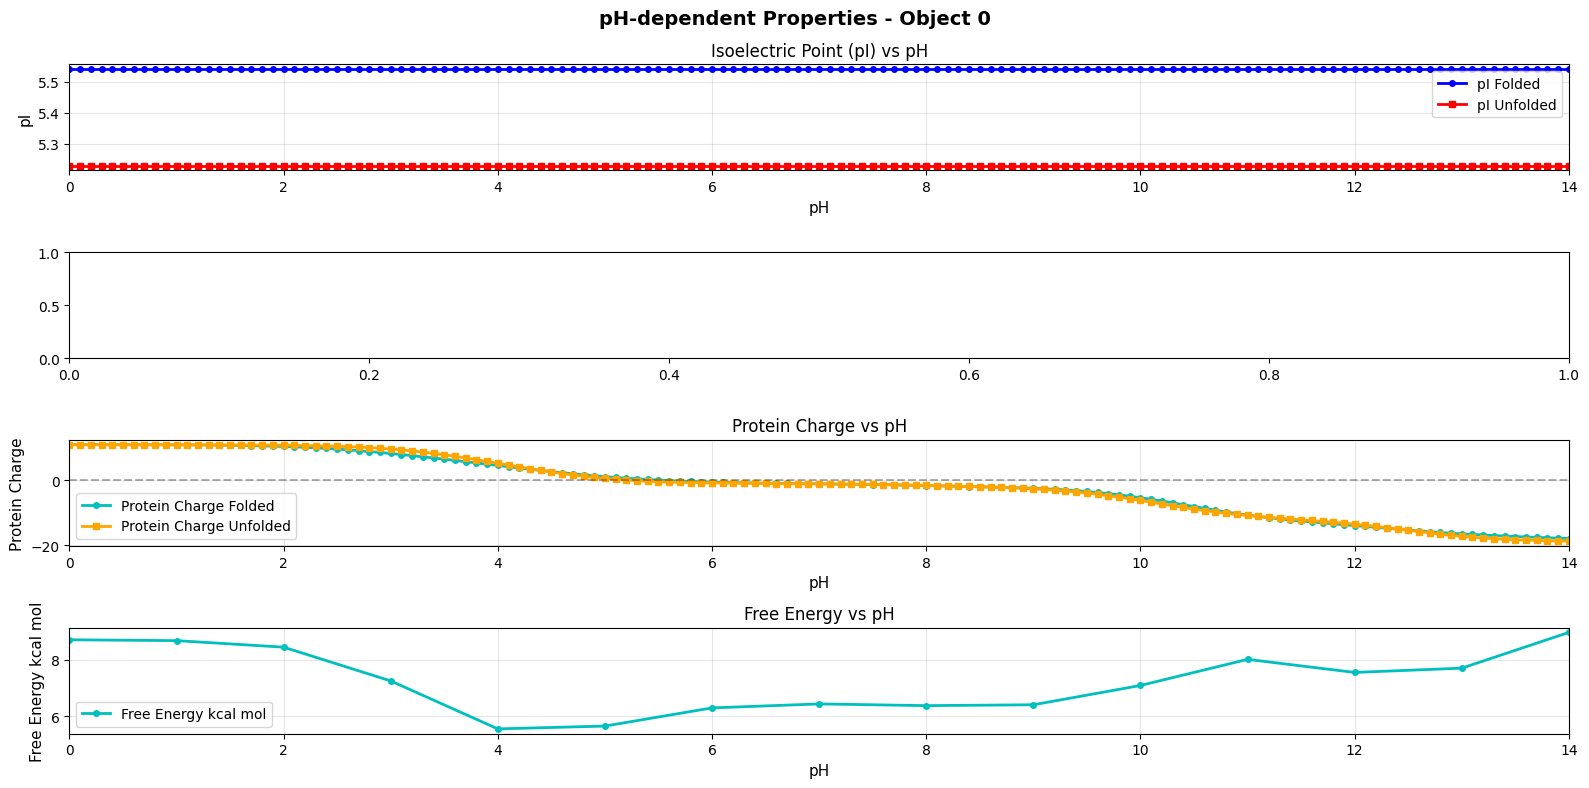

In [18]:
fig = analysis_descriptors.plot_ph_profiles(object_0_df, object_id=0)
plt.show()


# Residue mapping

In [19]:
df_heavy_final.style

,position_seq,position_num,amino_acid,region,disulfide_bond,sap,high_sap,sidechain_sasa,buried,pka,pka_shift,residue_sasa_sum,SASA,RASA,EXP_HSE_B_U,EXP_HSE_B_D,EXP_HSE_A_U,EXP_HSE_A_D,hydrophobicity,mean_IP,max_IP,min_IP,mean_dpx,CA_x,CA_y,CA_z,residue_name_U,charge,charge_sign,hydrophobicity_hw,hydrophobicity_eisenberg,hydrophobicity_rose,hydrophobicity_janin,hydrophobicity_engelman,Buried ratio_propka,Disolvation regular Cst_propka,Disolvation regular Nb_propka,Effects RE Cst_propka,Effects RE Nb_propka,Unpaired_Cys,N-linked_glycosylation,Met_oxidation,Trp_oxidation,Asn_deamidation,Asp_isomerisation,Lysine_Glycation,N-terminal_glutamate,Integrin_binding,CD11c/CD18_binding,Fragmentation,Polyreactivity
0,1,1.000000,D,fwh1,False,0.035079,False,112.578990,False,7.850000,-0.150000,112.578990,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1.000000,3.000000,-0.900000,0.620000,-0.600000,9.200000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
1,2,2.000000,V,fwh1,False,0.280271,False,39.747479,False,None,None,39.747479,57.930000,38.791000,9.000000,8.000000,8.000000,9.000000,4.200000,-0.024000,-0.253000,0.408000,1.909000,-13.448000,8.615000,3.893000,VAL,0.000000,0.000000,-1.500000,1.080000,0.860000,0.600000,-2.600000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
2,3,3.000000,Q,fwh1,False,0.141373,False,81.106193,False,None,None,81.106193,88.530000,49.739000,6.000000,17.000000,4.000000,19.000000,-3.500000,0.085000,-0.296000,1.063000,1.922000,-13.430000,5.361000,5.957000,GLN,0.000000,0.000000,0.200000,-0.850000,0.620000,-0.700000,4.100000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
3,4,4.000000,L,fwh1,False,0.005792,False,0.841492,True,None,None,0.841492,6.170000,3.469000,21.000000,12.000000,23.000000,10.000000,3.800000,-0.401000,-0.505000,-0.208000,2.595000,-12.911000,1.695000,5.418000,LEU,0.000000,0.000000,-1.800000,1.060000,0.850000,0.500000,-2.800000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
4,5,5.000000,V,fwh1,False,0.592469,True,84.022940,False,None,None,84.022940,91.480000,61.256000,4.000000,25.000000,2.000000,27.000000,4.200000,-0.037000,-0.269000,0.336000,1.629000,-13.904000,-0.711000,8.373000,VAL,0.000000,0.000000,-1.500000,1.080000,0.860000,0.600000,-2.600000,0,0.45,226,0.00,0,False,False,False,False,False,False,False,False,False,False,False,False
5,6,6.000000,E,fwh1,False,0.001171,False,3.758121,False,5.550000,1.300000,3.758121,21.390000,12.470000,19.000000,12.000000,23.000000,8.000000,-3.500000,-0.308000,-0.437000,-0.022000,2.484000,-12.865000,-4.265000,8.273000,GLU,-1.000000,-1.000000,3.000000,-0.740000,0.620000,-0.700000,8.200000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
6,7,7.000000,S,fwh1,False,0.287706,False,58.502988,False,None,None,58.502988,63.210000,54.822000,4.000000,23.000000,2.000000,25.000000,-0.800000,-0.031000,-0.289000,0.327000,1.962000,-14.498000,-7.179000,10.212000,SER,0.000000,0.000000,0.300000,-0.180000,0.660000,-0.100000,-0.600000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
7,8,8.000000,G,fwh1,False,0.000000,False,0.000000,False,None,None,0.000000,38.670000,48.013000,16.000000,11.000000,11.000000,16.000000,-0.400000,-0.028000,-0.146000,0.158000,1.524000,-14.414000,-11.073000,10.159000,GLY,0.000000,0.000000,0.000000,0.480000,0.720000,0.300000,-1.000000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
8,9,9.000000,G,fwh1,False,0.000000,False,0.000000,False,None,None,0.000000,32.690000,40.589000,14.000000,14.000000,21.000000,7.000000,-0.400000,-0.146000,-0.326000,0.108000,1.827000,-10.863000,-11.803000,11.113000,GLY,0.000000,0.000000,0.000000,0.480000,0.720000,0.300000,-1.000000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,Fa

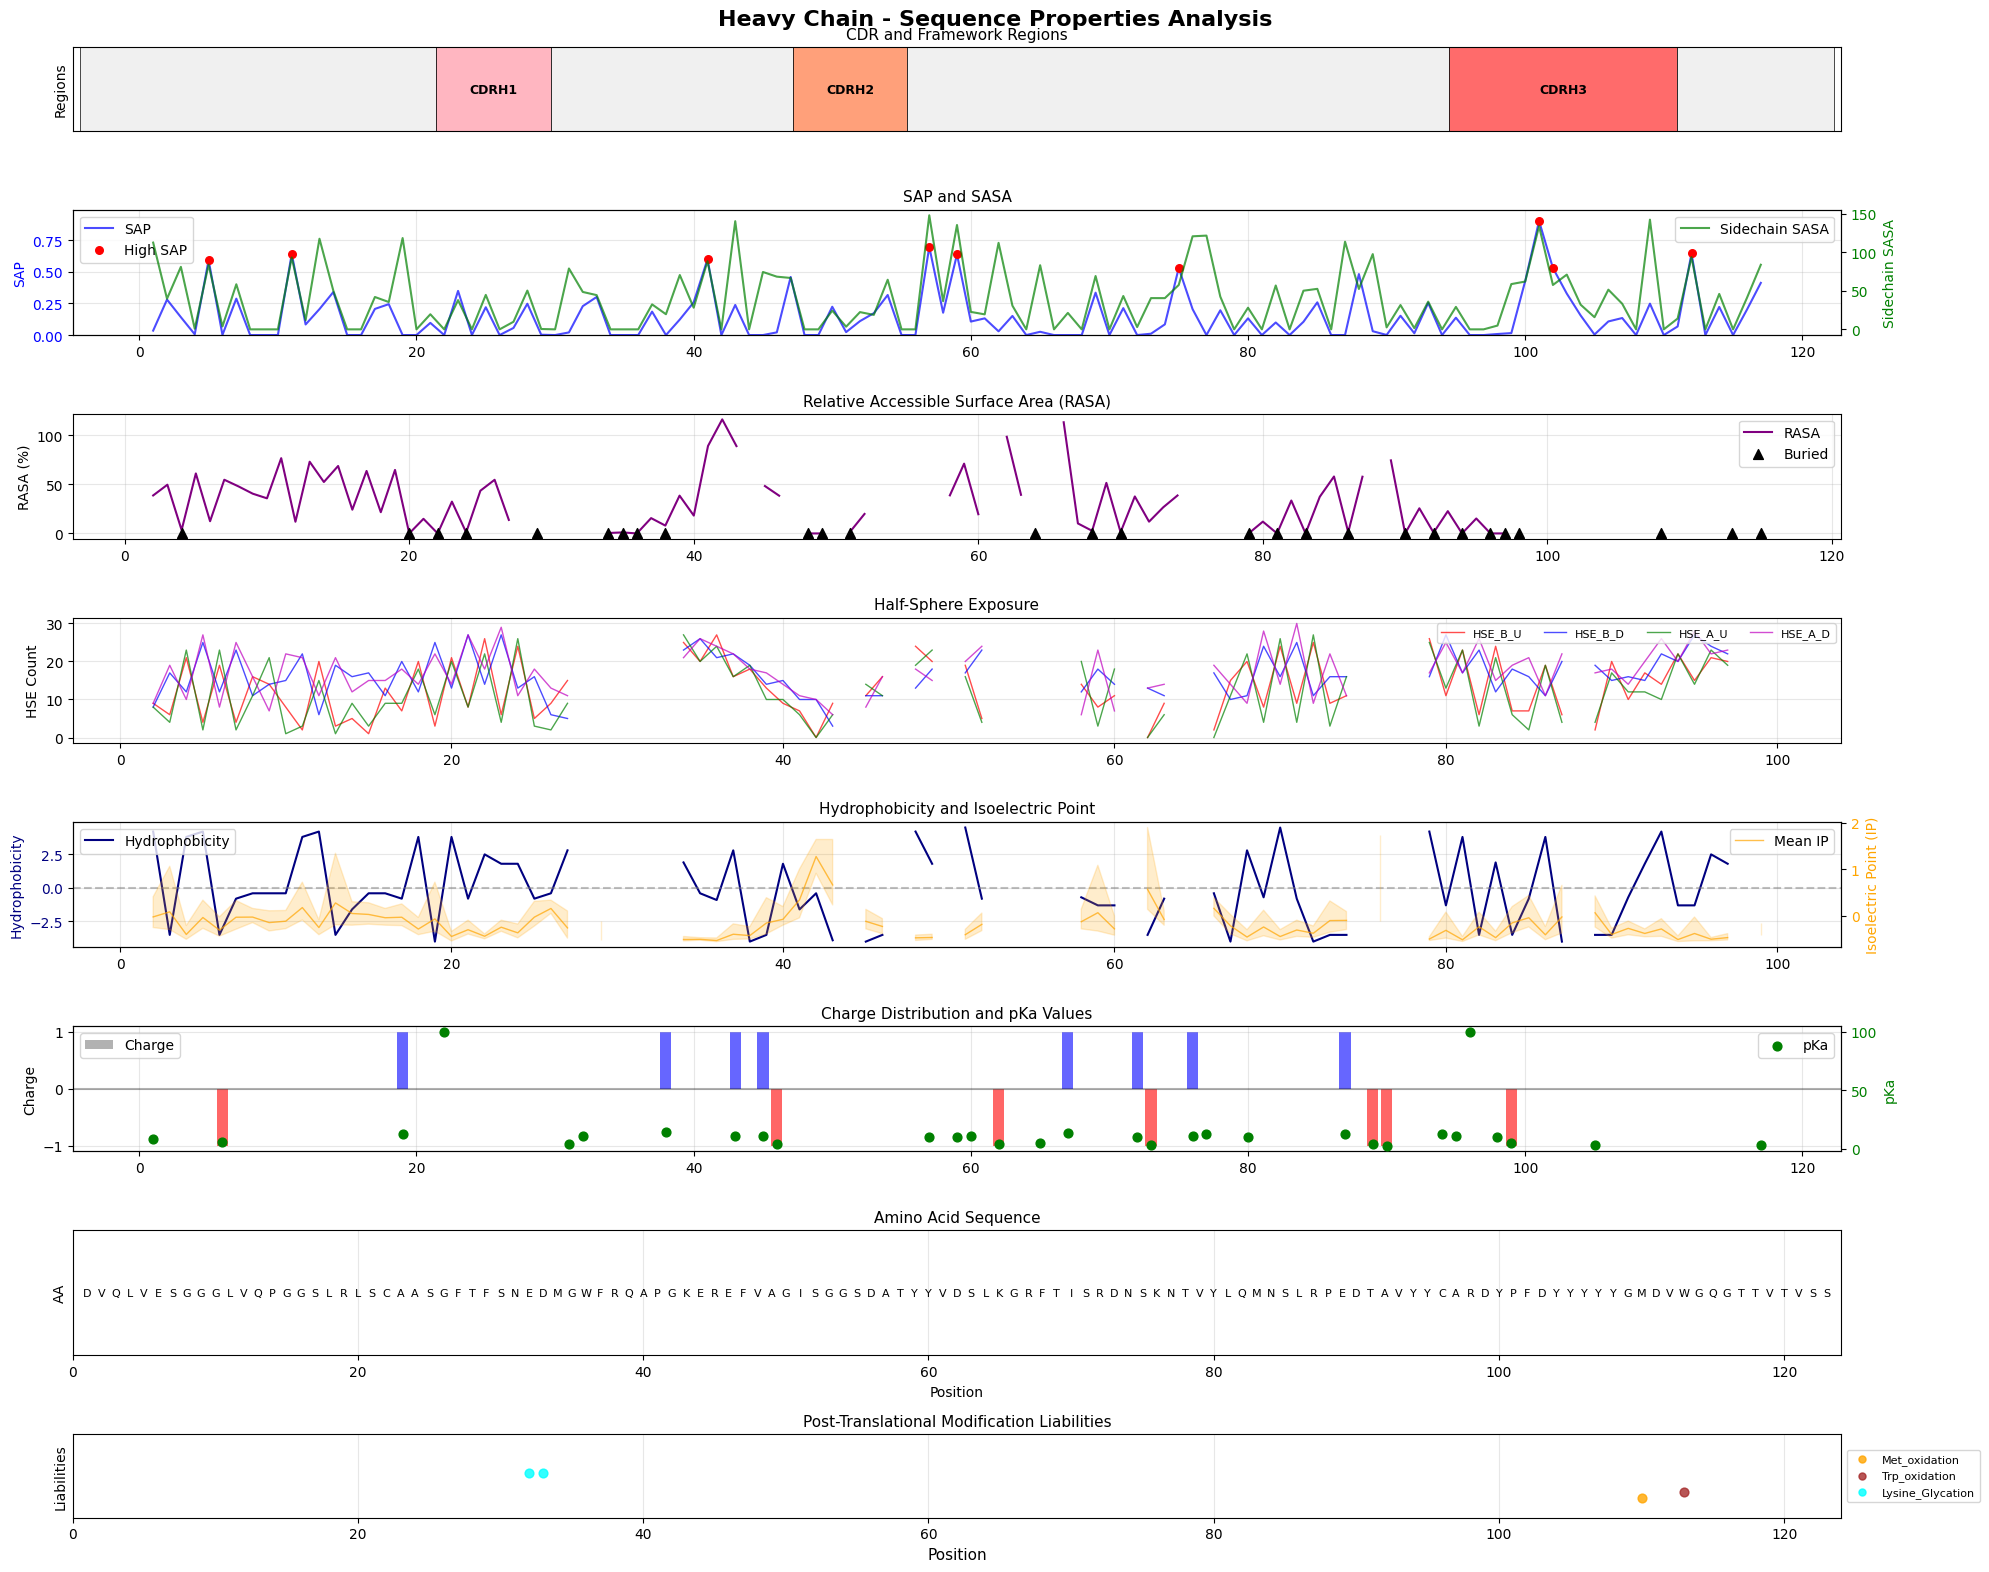

In [20]:
fig = analysis_descriptors.plot_protein_properties(df_heavy_final, chain_type='heavy')
plt.show()


TypeError: 'NoneType' object is not subscriptable

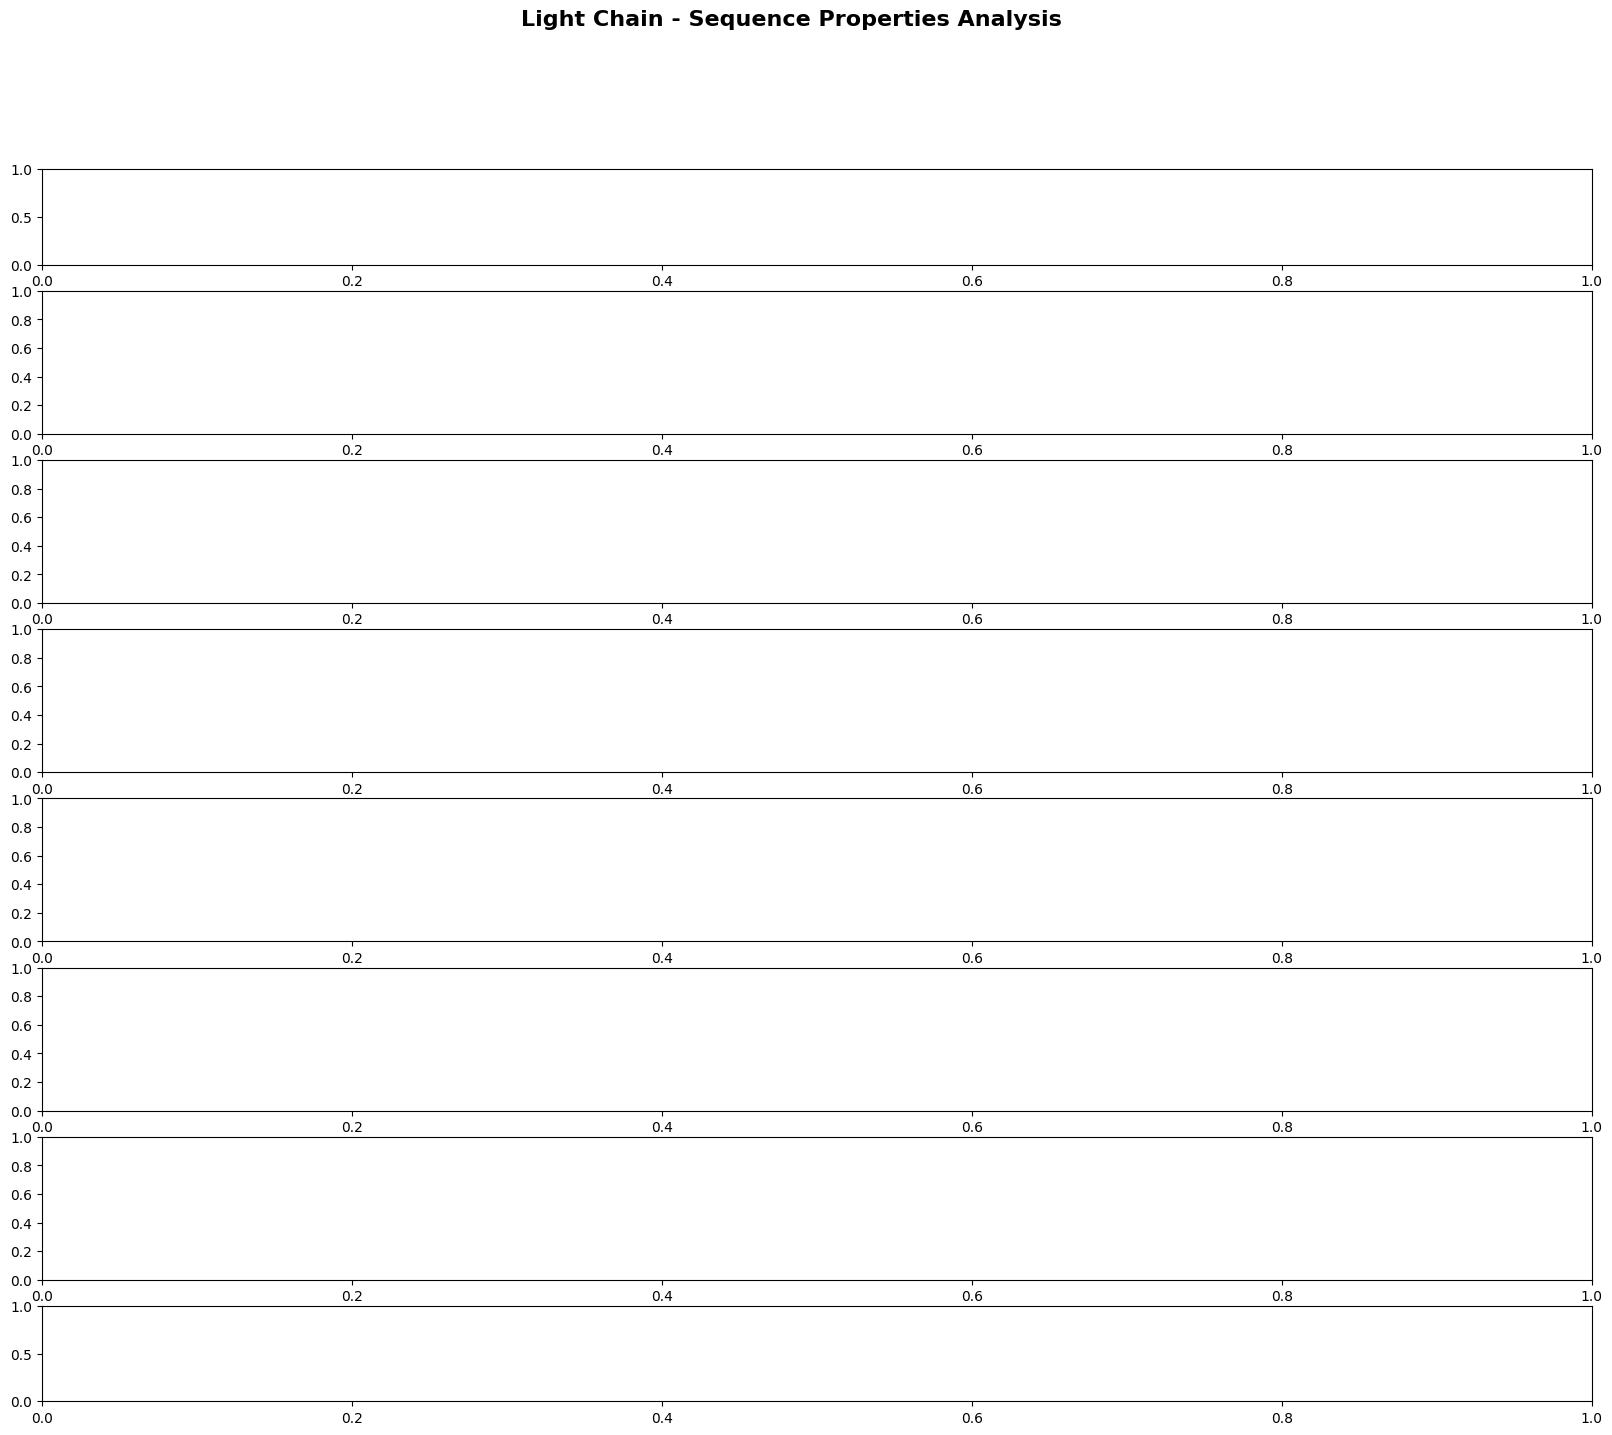

In [21]:
fig_heavy = analysis_descriptors.plot_protein_properties(df_light_final, chain_type='light')
plt.show()


# Propka spe

In [ ]:
fig_propka_heavy = analysis_descriptors.plot_propka_properties(df_heavy_final, chain_type='heavy')
plt.show()


In [ ]:
fig_propka_light = analysis_descriptors.plot_propka_properties(df_light_final, chain_type='light')
plt.show()

In [ ]:
df_light_final.style

In [28]:
1

1

In [1]:
import pandas as pd
df_vhh = pd.read_csv("VHH_descriptors_full.csv")

In [2]:
df_vhh


,heavy_sequence,light_sequence,scheme,Heavy_valid,Heavy_cdrh1,Heavy_cdrh2,Heavy_cdrh3,% Molecular Extinction Coefficient,% Molecular Extinction Coefficient (Cysteine bridges),Acidic content,...,surface_vs_buried_ip_diff,theoretical_pi_pH7.4,titratable_residues,total_MW,total_cys,total_exposed,total_possible,total_sasa,total_sasa_sidechain,unusual_pka_count
0,DVQLVESGGGLVQPGGSLRLSCAASGFGVSSTYMGWFRQAPGKERE...,NaN,imgt,True,GFGVSSTY,ISGTAGDT,FTVTTPQYFDY,17.969859,0.097472,8.474576,...,0.465697,5.698211,30.0,14931.94,2,65,12,6440.758133,4904.478226,3.0
1,DVQLVESGGGLVQPGGSLRLSCAASGFGVTGTYMGWFRQAPGKERE...,NaN,imgt,True,GFGVTGTY,ISGTAGDT,ARWDQLEYYYGMDV,22.713048,0.094527,9.917355,...,0.449091,5.698211,33.0,15385.42,2,63,12,6451.112402,4822.466390,5.0
2,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,NaN,imgt,True,GFPFSSYP,ISGSATGT,AGINRAGLGRYYFDY,18.538280,0.094448,7.377049,...,0.489301,5.698211,32.0,15414.50,2,63,12,6691.968260,5031.973754,4.0
3,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,NaN,imgt,True,GFPFSSYP,ISGSATGT,AKDADIVATAAGGPADY,16.448449,0.095387,8.870968,...,0.512046,5.698211,31.0,15320.32,2,69,12,6727.168082,4987.614177,3.0
4,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,NaN,imgt,True,GFPFSSYP,ISGSATGT,ARDPDIVVVPAGEMTNHHSDY,15.594276,0.090433,9.375000,...,0.555505,5.698211,34.0,16110.20,2,70,12,7333.505944,5460.541576,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,QVQLVESGGGLVQPGGSLRLSCAASGSISDINVMSWYRQAPGKERV...,NaN,imgt,True,GSISDINV,IGSGGGT,NVVEWSASATPSDY,20.077598,0.098169,9.166667,...,0.475632,6.525488,29.0,14876.81,2,65,12,6500.670152,4838.402585,2.0
396,QVQLVESGGGLVQTGGSLRLSCLASGRTSSIYNMGWFRQAPGEERE...,NaN,imgt,True,GRTSSIYN,ISRNGGST,SANSRGTSTTIQPEY,15.068652,0.093874,7.377049,...,0.491846,6.525488,32.0,15495.47,2,68,12,6842.983805,5212.882250,4.0
397,QVQLVESGGGLVQTGGSLRLSCAASGFTFSIKHMAWYRQAPGKQRE...,NaN,imgt,True,GFTFSIKH,IFISSTT,NALSPAWES,23.455101,0.099134,6.086957,...,0.457561,6.525488,27.0,14662.84,2,63,12,6077.021578,4607.393683,6.0
398,QVQLVESGGGLVQTGGSLTLSCAASGGTFRPRIMGWFRQAPGKERE...,NaN,imgt,True,GGTFRPRI,IKAGTGRT,AADYSAFTSLENPRSADFGA,13.681076,0.092066,7.874016,...,0.511001,6.525488,31.0,15846.95,2,72,12,7408.817016,5580.273209,5.0


In [3]:
out_ = []
for col in df_vhh.columns.to_list():
    if "protpy" not in col:
        out_.append(col)

In [4]:
df_vhh = df_vhh[out_]

In [7]:
df_vhh["Identifier"] = ids_Ab

/var/tmp/ipykernel_601393/4021883551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vhh["Identifier"] = ids_Ab


In [8]:
df_vhh

,heavy_sequence,light_sequence,scheme,Heavy_valid,Heavy_cdrh1,Heavy_cdrh2,Heavy_cdrh3,% Molecular Extinction Coefficient,% Molecular Extinction Coefficient (Cysteine bridges),Acidic content,...,theoretical_pi_pH7.4,titratable_residues,total_MW,total_cys,total_exposed,total_possible,total_sasa,total_sasa_sidechain,unusual_pka_count,Identifier
0,DVQLVESGGGLVQPGGSLRLSCAASGFGVSSTYMGWFRQAPGKERE...,NaN,imgt,True,GFGVSSTY,ISGTAGDT,FTVTTPQYFDY,17.969859,0.097472,8.474576,...,5.698211,30.0,14931.94,2,65,12,6440.758133,4904.478226,3.0,BsAb-3981-[38133.38699-38133.38509]
1,DVQLVESGGGLVQPGGSLRLSCAASGFGVTGTYMGWFRQAPGKERE...,NaN,imgt,True,GFGVTGTY,ISGTAGDT,ARWDQLEYYYGMDV,22.713048,0.094527,9.917355,...,5.698211,33.0,15385.42,2,63,12,6451.112402,4822.466390,5.0,BsAb-3982-[38134.38700-38134.38510]
2,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,NaN,imgt,True,GFPFSSYP,ISGSATGT,AGINRAGLGRYYFDY,18.538280,0.094448,7.377049,...,5.698211,32.0,15414.50,2,63,12,6691.968260,5031.973754,4.0,BsAb-4600-[39296.39495-39296.39581]
3,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,NaN,imgt,True,GFPFSSYP,ISGSATGT,AKDADIVATAAGGPADY,16.448449,0.095387,8.870968,...,5.698211,31.0,15320.32,2,69,12,6727.168082,4987.614177,3.0,BsAb-4604-[39300.39499-39300.39585]
4,DVQLVESGGGLVQPGGSLRLSCAASGFPFSSYPMGWFRQAPGKERE...,NaN,imgt,True,GFPFSSYP,ISGSATGT,ARDPDIVVVPAGEMTNHHSDY,15.594276,0.090433,9.375000,...,5.698211,34.0,16110.20,2,70,12,7333.505944,5460.541576,3.0,BsAb-4605-[39301.39500-39301.39586]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,QVQLVESGGGLVQPGGSLRLSCAASGSISDINVMSWYRQAPGKERV...,NaN,imgt,True,GSISDINV,IGSGGGT,NVVEWSASATPSDY,20.077598,0.098169,9.166667,...,6.525488,29.0,14876.81,2,65,12,6500.670152,4838.402585,2.0,BsAb-3505-[37389.37427-37389.37389]
396,QVQLVESGGGLVQTGGSLRLSCLASGRTSSIYNMGWFRQAPGEERE...,NaN,imgt,True,GRTSSIYN,ISRNGGST,SANSRGTSTTIQPEY,15.068652,0.093874,7.377049,...,6.525488,32.0,15495.47,2,68,12,6842.983805,5212.882250,4.0,BsAb-3087-[37253.37348-37253.37253]
397,QVQLVESGGGLVQTGGSLRLSCAASGFTFSIKHMAWYRQAPGKQRE...,NaN,imgt,True,GFTFSIKH,IFISSTT,NALSPAWES,23.455101,0.099134,6.086957,...,6.525488,27.0,14662.84,2,63,12,6077.021578,4607.393683,6.0,BsAb-3086-[37252.37347-37252.37252]
398,QVQLVESGGGLVQTGGSLTLSCAASGGTFRPRIMGWFRQAPGKERE...,NaN,imgt,True,GGTFRPRI,IKAGTGRT,AADYSAFTSLENPRSADFGA,13.681076,0.092066,7.874016,...,6.525488,31.0,15846.95,2,72,12,7408.817016,5580.273209,5.0,BsAb-3088-[37254.37349-37254.37254]


In [9]:
df_vhh.to_csv("descriptor_pipeline_sample.csv", index = False)